# SpaceX Falcon 9 – EDA with Data Visualization and Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv')
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


## Flight Number vs. Payload Mass

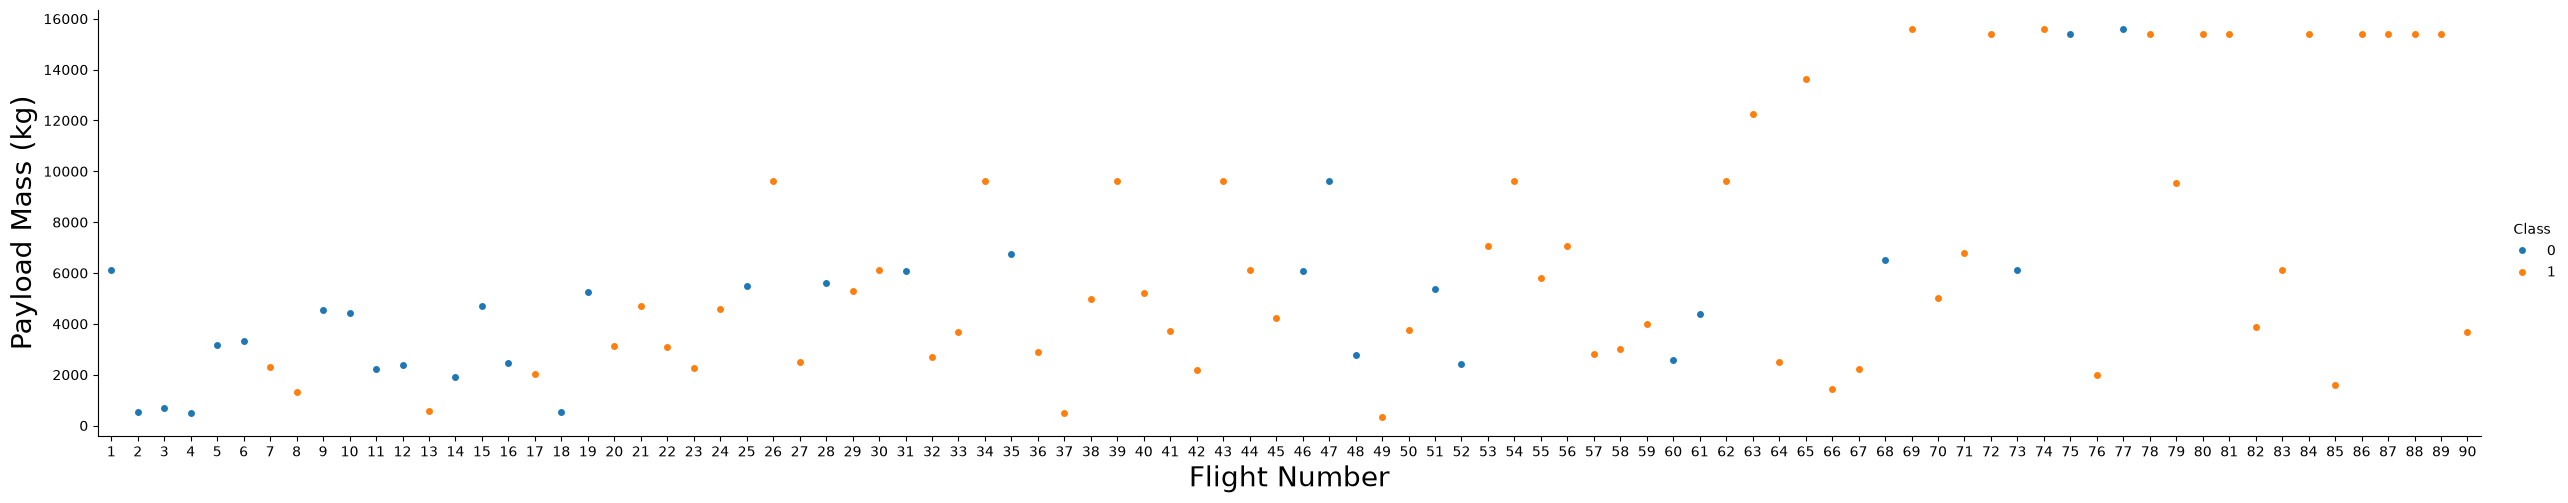

In [2]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Payload Mass (kg)", fontsize=20)
plt.savefig("images/eda_flight_payload.png", bbox_inches="tight", dpi=110)
plt.show()

## Task 1: Flight Number vs. Launch Site

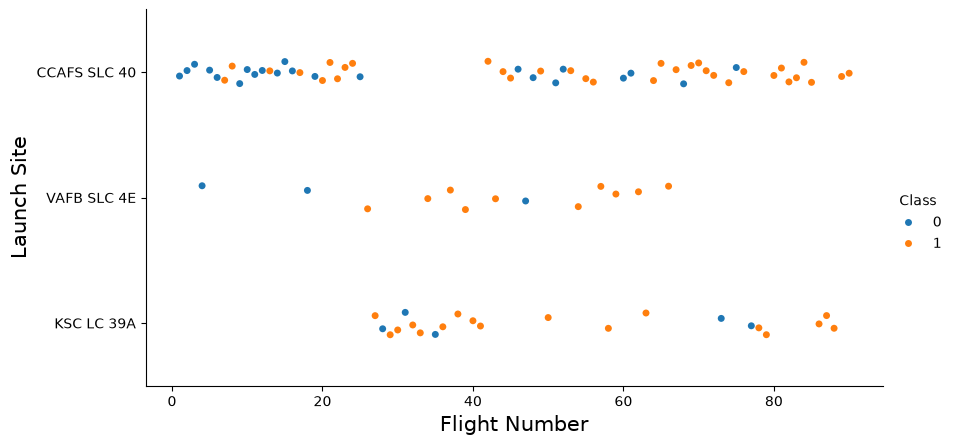

In [3]:
sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, aspect=2, height=4.5)
plt.xlabel("Flight Number", fontsize=15)
plt.ylabel("Launch Site", fontsize=15)
plt.savefig("images/eda_flight_site.png", bbox_inches="tight", dpi=110)
plt.show()

## Task 2: Payload Mass vs. Launch Site

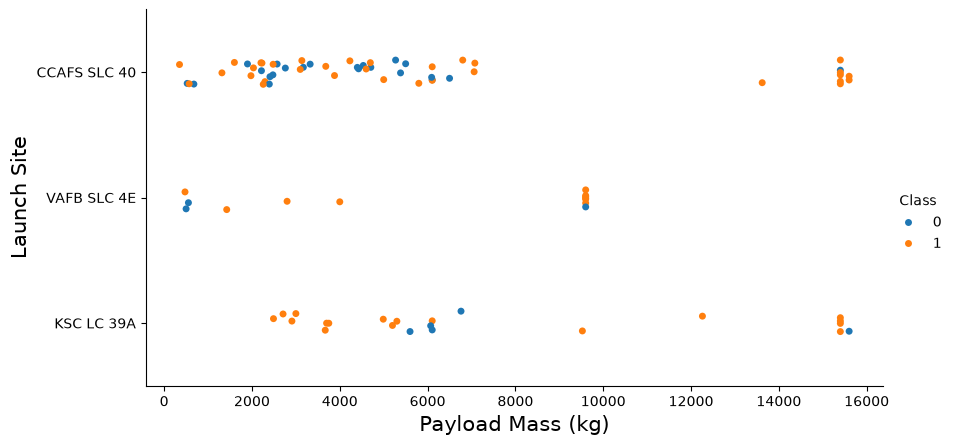

In [4]:
sns.catplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df, aspect=2, height=4.5)
plt.xlabel("Payload Mass (kg)", fontsize=15)
plt.ylabel("Launch Site", fontsize=15)
plt.savefig("images/eda_payload_site.png", bbox_inches="tight", dpi=110)
plt.show()

## Task 3: Success rate of each orbit type

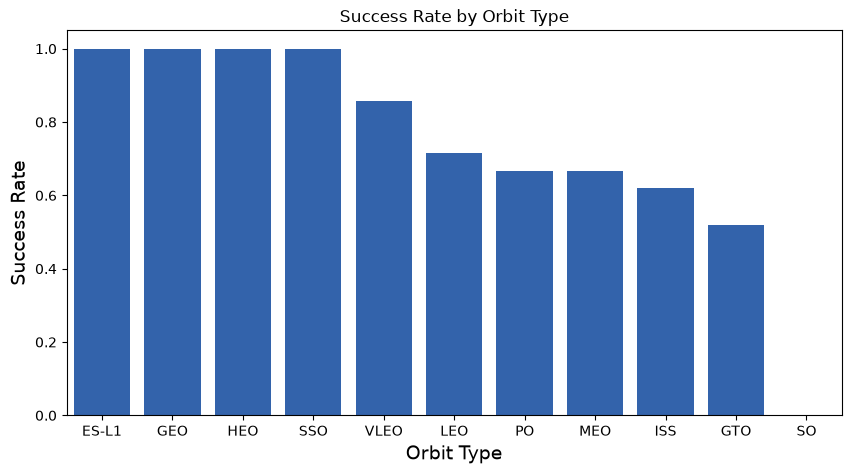

,Orbit,Class
0,ES-L1,1.000000
1,GEO,1.000000
2,HEO,1.000000
3,SSO,1.000000
4,VLEO,0.857143
5,LEO,0.714286
6,PO,0.666667
7,MEO,0.666667
8,ISS,0.619048
9,GTO,0.518519


In [5]:
orbit_rate = df.groupby('Orbit')['Class'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(x='Orbit', y='Class', data=orbit_rate, color='#1f5fbf')
plt.xlabel("Orbit Type", fontsize=14)
plt.ylabel("Success Rate", fontsize=14)
plt.title("Success Rate by Orbit Type")
plt.savefig("images/eda_orbit_success.png", bbox_inches="tight", dpi=110)
plt.show()
orbit_rate

## Task 4: Flight Number vs. Orbit type

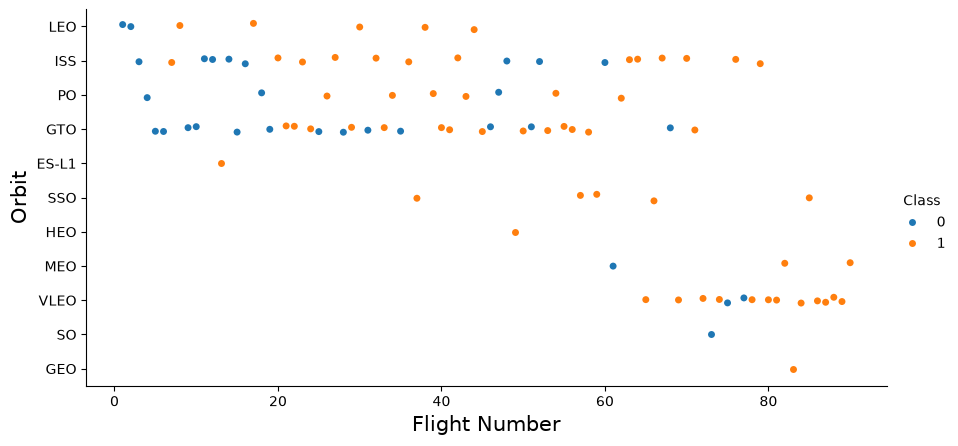

In [6]:
sns.catplot(y="Orbit", x="FlightNumber", hue="Class", data=df, aspect=2, height=4.5)
plt.xlabel("Flight Number", fontsize=15)
plt.ylabel("Orbit", fontsize=15)
plt.savefig("images/eda_flight_orbit.png", bbox_inches="tight", dpi=110)
plt.show()

## Task 5: Payload Mass vs. Orbit type

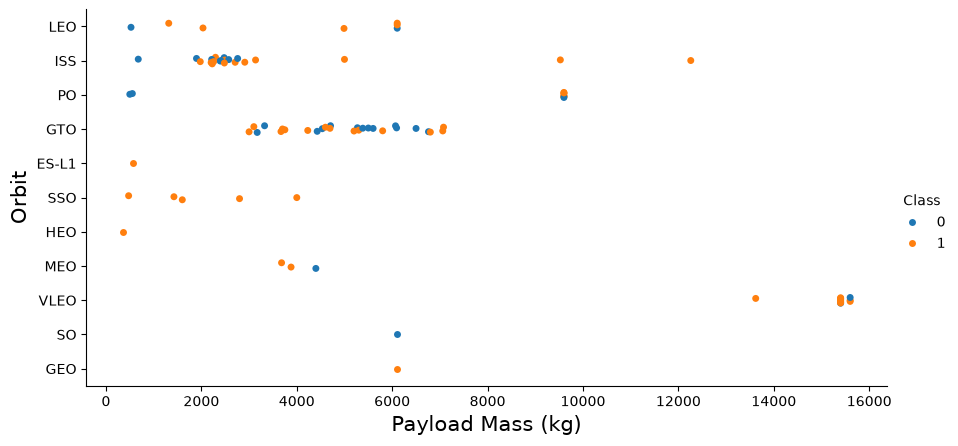

In [7]:
sns.catplot(y="Orbit", x="PayloadMass", hue="Class", data=df, aspect=2, height=4.5)
plt.xlabel("Payload Mass (kg)", fontsize=15)
plt.ylabel("Orbit", fontsize=15)
plt.savefig("images/eda_payload_orbit.png", bbox_inches="tight", dpi=110)
plt.show()

## Task 6: Launch success yearly trend

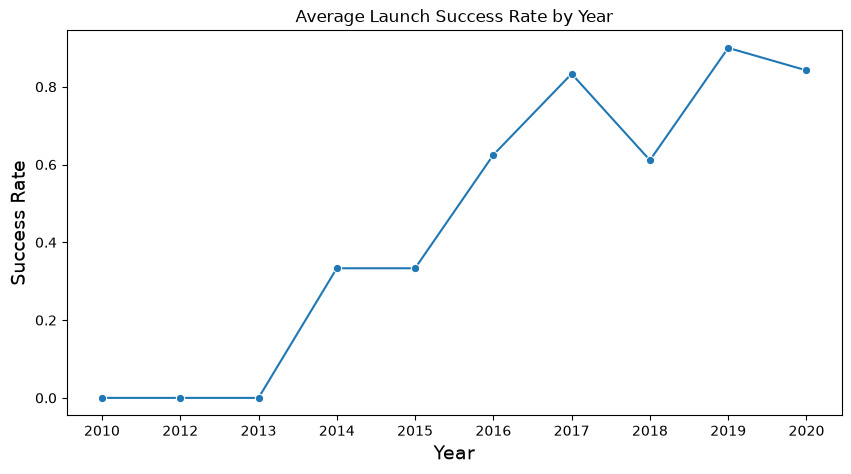

,Date,Class
0,2010,0.000000
1,2012,0.000000
2,2013,0.000000
3,2014,0.333333
4,2015,0.333333
5,2016,0.625000
6,2017,0.833333
7,2018,0.611111
8,2019,0.900000
9,2020,0.842105


In [8]:
year = []
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
df['Date'] = Extract_year()

yearly = df.groupby('Date')['Class'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(x='Date', y='Class', data=yearly, marker='o')
plt.xlabel("Year", fontsize=14)
plt.ylabel("Success Rate", fontsize=14)
plt.title("Average Launch Success Rate by Year")
plt.savefig("images/eda_yearly_trend.png", bbox_inches="tight", dpi=110)
plt.show()
yearly

## Additional analysis: launch records per site

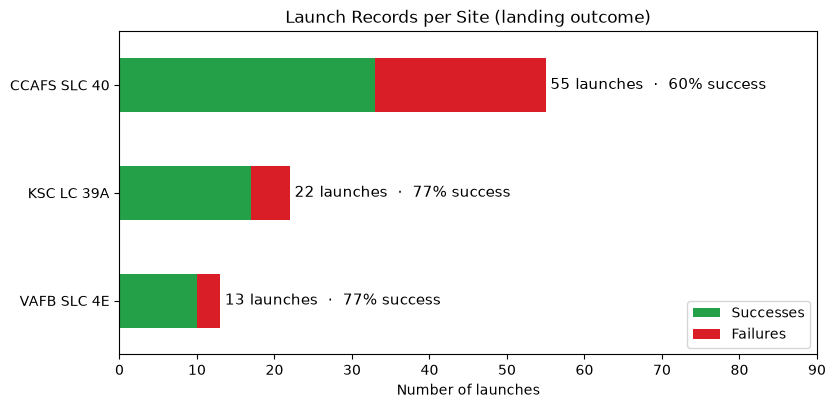

,Launches,Successes,Failures,Success Rate
LaunchSite,,,,
CCAFS SLC 40,55,33,22,0.600
KSC LC 39A,22,17,5,0.773
VAFB SLC 4E,13,10,3,0.769


In [9]:
site = df.groupby('LaunchSite')['Class'].agg(Launches='count', Successes='sum')
site['Failures'] = site['Launches'] - site['Successes']
site['Success Rate'] = (site['Successes'] / site['Launches']).round(3)
site = site.sort_values('Launches', ascending=False)
site.to_csv('results/launches_per_site.csv')

ax = site[['Successes', 'Failures']].plot(kind='barh', stacked=True, color=['#24a148', '#da1e28'], figsize=(9, 4.2))
for i, (n, r) in enumerate(zip(site['Launches'], site['Success Rate'])):
    ax.text(n + 0.6, i, f"{n} launches  ·  {r:.0%} success", va='center', fontsize=11)
ax.invert_yaxis()
ax.set_xlim(0, 90)
ax.set_xlabel('Number of launches')
ax.set_ylabel('')
ax.set_title('Launch Records per Site (landing outcome)')
plt.savefig('images/eda_launches_per_site.png', bbox_inches='tight', dpi=130)
plt.show()
site

## Additional analysis: booster hardware and reuse

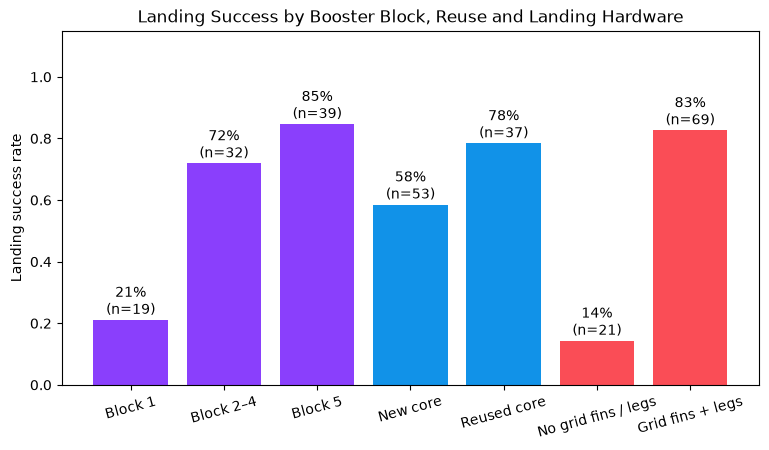

,Group,Launches,Success Rate
0,Block 1,19,0.210526
1,Block 2–4,32,0.718750
2,Block 5,39,0.846154
3,New core,53,0.584906
4,Reused core,37,0.783784
5,No grid fins / legs,21,0.142857
6,Grid fins + legs,69,0.826087


In [10]:
groups = {
    'Block 1': df['Block'] == 1, 'Block 2–4': df['Block'].between(2, 4), 'Block 5': df['Block'] == 5,
    'New core': ~df['Reused'], 'Reused core': df['Reused'],
    'No grid fins / legs': ~(df['GridFins'] & df['Legs']), 'Grid fins + legs': df['GridFins'] & df['Legs'],
}
insight = pd.DataFrame({'Group': list(groups),
                        'Launches': [int(m.sum()) for m in groups.values()],
                        'Success Rate': [df.loc[m, 'Class'].mean() for m in groups.values()]})
insight.to_csv('results/hardware_insights.csv', index=False)

colors = ['#8a3ffc'] * 3 + ['#1192e8'] * 2 + ['#fa4d56'] * 2
fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.bar(insight['Group'], insight['Success Rate'], color=colors)
for b, n, r in zip(bars, insight['Launches'], insight['Success Rate']):
    ax.text(b.get_x() + b.get_width() / 2, r + 0.02, f"{r:.0%}\n(n={n})", ha='center', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Landing success rate')
ax.set_title('Landing Success by Booster Block, Reuse and Landing Hardware')
plt.xticks(rotation=15)
plt.savefig('images/eda_hardware_insights.png', bbox_inches='tight', dpi=130)
plt.show()
insight

## Features Engineering

In [11]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused',
               'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


## Task 7: Create dummy variables for the categorical columns

In [12]:
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
print(features_one_hot.shape)
features_one_hot.head()

(90, 80)


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


## Task 8: Cast all numeric columns to float64

In [13]:
features_one_hot = features_one_hot.astype('float64')
features_one_hot.to_csv('dataset_part_3.csv', index=False)